# Customer Churn Prediction Model

## End-to-End Machine Learning Pipeline

This notebook demonstrates a complete machine learning workflow for predicting customer churn using telecom customer data. We'll preprocess the data, train multiple classifiers, and evaluate their performance using advanced metrics.

## Section 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, 
                             precision_recall_curve, precision_score, recall_score, 
                             f1_score, accuracy_score, classification_report)
from sklearn.utils import resample
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("All libraries loaded successfully!")

All libraries loaded successfully!


## Section 2: Load and Explore Telecom Customer Data

In [3]:
# Generate synthetic telecom customer churn dataset
np.random.seed(42)
n_samples = 5000

data = {
    'tenure': np.random.randint(1, 73, n_samples),
    'MonthlyCharges': np.random.uniform(18, 118, n_samples),
    'TotalCharges': np.random.uniform(18, 8684, n_samples),
    'age': np.random.randint(18, 80, n_samples),
    'number_of_dependents': np.random.randint(0, 4, n_samples),
    'phone_service': np.random.choice(['Yes', 'No'], n_samples),
    'internet_service': np.random.choice(['Fiber optic', 'DSL', 'No'], n_samples),
    'online_security': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
    'tech_support': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
    'contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n_samples),
    'paperless_billing': np.random.choice(['Yes', 'No'], n_samples),
}

# Create target variable with some correlation to features
churn_probability = (
    0.3 * (data['tenure'] < 20) +
    0.2 * (data['MonthlyCharges'] > 80) +
    0.2 * (np.array(data['contract']) == 'Month-to-month') +
    0.15 * (np.array(data['internet_service']) == 'Fiber optic') +
    0.15 * (np.array(data['tech_support']) == 'No')
) / 1.0
churn_probability = np.clip(churn_probability, 0, 1)
data['Churn'] = (np.random.random(n_samples) < churn_probability).astype(int)

# Add some missing values randomly
missing_indices = np.random.choice(n_samples, size=int(0.05 * n_samples), replace=False)
for idx in missing_indices[:len(missing_indices)//2]:
    data['MonthlyCharges'][idx] = np.nan

df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)
print("\nFirst Few Rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (5000, 12)

First Few Rows:
   tenure  MonthlyCharges  TotalCharges  age  number_of_dependents  \
0      52      116.950533   1466.385973   75                     1   
1      15             NaN   3546.567619   28                     1   
2      72      112.898067   2030.880979   70                     1   
3      61             NaN   4652.585266   60                     2   
4      21       56.213947   1741.048043   35                     0   

  phone_service internet_service      online_security         tech_support  \
0           Yes               No                  Yes                   No   
1            No      Fiber optic  No internet service                   No   
2           Yes               No                   No  No internet service   
3           Yes      Fiber optic                  Yes  No internet service   
4            No      Fiber optic                   No                   No   

         contract paperless_billing  Churn  
0        One year     

## Section 3: Preprocess Data - Handle Missing Values and Encode Categorical Features

In [4]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n")

# Handle missing values
print("Handling missing values:")
# Fill numerical missing values with median
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Filled missing values in {col} with median")

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"\nTarget Variable Distribution:")
print(y.value_counts())
print(f"Churn Rate: {y.mean():.2%}")

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

print(f"\nCategorical Features: {categorical_cols}")
print(f"Numerical Features: {numerical_cols}")

# Encode categorical variables using one-hot encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\nShape after encoding: {X_encoded.shape}")
print(f"\nEncoded Features:\n{X_encoded.head()}")

Missing Values:
tenure                    0
MonthlyCharges          125
TotalCharges              0
age                       0
number_of_dependents      0
phone_service             0
internet_service          0
online_security           0
tech_support              0
contract                  0
paperless_billing         0
Churn                     0
dtype: int64


Handling missing values:
Filled missing values in MonthlyCharges with median

Target Variable Distribution:
Churn
0    3418
1    1582
Name: count, dtype: int64
Churn Rate: 31.64%

Categorical Features: ['phone_service', 'internet_service', 'online_security', 'tech_support', 'contract', 'paperless_billing']
Numerical Features: ['MonthlyCharges', 'TotalCharges']

Shape after encoding: (5000, 15)

Encoded Features:
   tenure  MonthlyCharges  TotalCharges  age  number_of_dependents  \
0      52      116.950533   1466.385973   75                     1   
1      15             NaN   3546.567619   28                     1   
2      

## Section 4: Balance Classes Using Resampling

In [5]:
# Check class imbalance
print("Original Class Distribution:")
print(y.value_counts())
print(f"Class Imbalance Ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}:1")

# Apply oversampling to balance classes
# Separate majority and minority classes
X_majority = X_encoded[y == 0]
X_minority = X_encoded[y == 1]
y_majority = y[y == 0]
y_minority = y[y == 1]

# Oversample minority class
X_minority_resampled = resample(X_minority, 
                                n_samples=len(X_majority), 
                                random_state=42)
y_minority_resampled = resample(y_minority, 
                                n_samples=len(y_majority), 
                                random_state=42)

# Combine majority and oversampled minority
X_balanced = pd.concat([X_majority, X_minority_resampled])
y_balanced = pd.concat([y_majority, y_minority_resampled])

print(f"\nBalanced Class Distribution:")
print(y_balanced.value_counts())
print(f"New Class Balance: {y_balanced.value_counts()[0] / y_balanced.value_counts()[1]:.2f}:1")

# Shuffle the balanced dataset
shuffle_idx = np.random.permutation(len(X_balanced))
X_balanced = X_balanced.iloc[shuffle_idx].reset_index(drop=True)
y_balanced = y_balanced.iloc[shuffle_idx].reset_index(drop=True)

print(f"\nBalanced Dataset Shape: X={X_balanced.shape}, y={y_balanced.shape}")

Original Class Distribution:
Churn
0    3418
1    1582
Name: count, dtype: int64
Class Imbalance Ratio: 2.16:1

Balanced Class Distribution:
Churn
0    3418
1    3418
Name: count, dtype: int64
New Class Balance: 1.00:1

Balanced Dataset Shape: X=(6836, 15), y=(6836,)


## Section 5: Split Data into Training and Testing Sets

In [8]:
# Split into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

# Remove any rows with NaN values
train_mask = ~(X_train.isnull().any(axis=1))
test_mask = ~(X_test.isnull().any(axis=1))

X_train = X_train[train_mask].reset_index(drop=True)
y_train = y_train[train_mask].reset_index(drop=True)
X_test = X_test[test_mask].reset_index(drop=True)
y_test = y_test[test_mask].reset_index(drop=True)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training and Testing Split:")
print(f"Training Set: X_train={X_train_scaled.shape}, y_train={y_train.shape}")
print(f"Testing Set: X_test={X_test_scaled.shape}, y_test={y_test.shape}")
print(f"\nTraining Set Class Distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTesting Set Class Distribution:")
print(pd.Series(y_test).value_counts())

Training and Testing Split:
Training Set: X_train=(5307, 15), y_train=(5307,)
Testing Set: X_test=(1337, 15), y_test=(1337,)

Training Set Class Distribution:
Churn
0    2662
1    2645
Name: count, dtype: int64

Testing Set Class Distribution:
Churn
1    670
0    667
Name: count, dtype: int64


## Section 6: Train Logistic Regression Classifier

In [9]:
# Initialize and train Logistic Regression
print("Training Logistic Regression Classifier...")
start_time = time.time()

lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)

lr_training_time = time.time() - start_time
print(f"Training Time: {lr_training_time:.4f} seconds")

# Make predictions
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)
lr_train_pred_proba = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_test_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate initial metrics
lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_test_acc = accuracy_score(y_test, lr_test_pred)
lr_train_auc = roc_auc_score(y_train, lr_train_pred_proba)
lr_test_auc = roc_auc_score(y_test, lr_test_pred_proba)

print(f"\nLogistic Regression Performance:")
print(f"Training Accuracy: {lr_train_acc:.4f}")
print(f"Testing Accuracy: {lr_test_acc:.4f}")
print(f"Training ROC-AUC: {lr_train_auc:.4f}")
print(f"Testing ROC-AUC: {lr_test_auc:.4f}")

Training Logistic Regression Classifier...
Training Time: 0.0270 seconds

Logistic Regression Performance:
Training Accuracy: 0.6806
Testing Accuracy: 0.6941
Training ROC-AUC: 0.7496
Testing ROC-AUC: 0.7522


## Section 7: Train Random Forest Classifier

In [10]:
# Initialize and train Random Forest
print("Training Random Forest Classifier...")
start_time = time.time()

rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, 
                                  random_state=42, n_jobs=-1, 
                                  min_samples_split=5, min_samples_leaf=2)
rf_model.fit(X_train_scaled, y_train)

rf_training_time = time.time() - start_time
print(f"Training Time: {rf_training_time:.4f} seconds")

# Make predictions
rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)
rf_train_pred_proba = rf_model.predict_proba(X_train_scaled)[:, 1]
rf_test_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate initial metrics
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)
rf_train_auc = roc_auc_score(y_train, rf_train_pred_proba)
rf_test_auc = roc_auc_score(y_test, rf_test_pred_proba)

print(f"\nRandom Forest Performance:")
print(f"Training Accuracy: {rf_train_acc:.4f}")
print(f"Testing Accuracy: {rf_test_acc:.4f}")
print(f"Training ROC-AUC: {rf_train_auc:.4f}")
print(f"Testing ROC-AUC: {rf_test_auc:.4f}")

Training Random Forest Classifier...
Training Time: 0.3518 seconds

Random Forest Performance:
Training Accuracy: 0.9864
Testing Accuracy: 0.8362
Training ROC-AUC: 0.9993
Testing ROC-AUC: 0.9306


## Section 8: Evaluate Models with ROC-AUC Curves

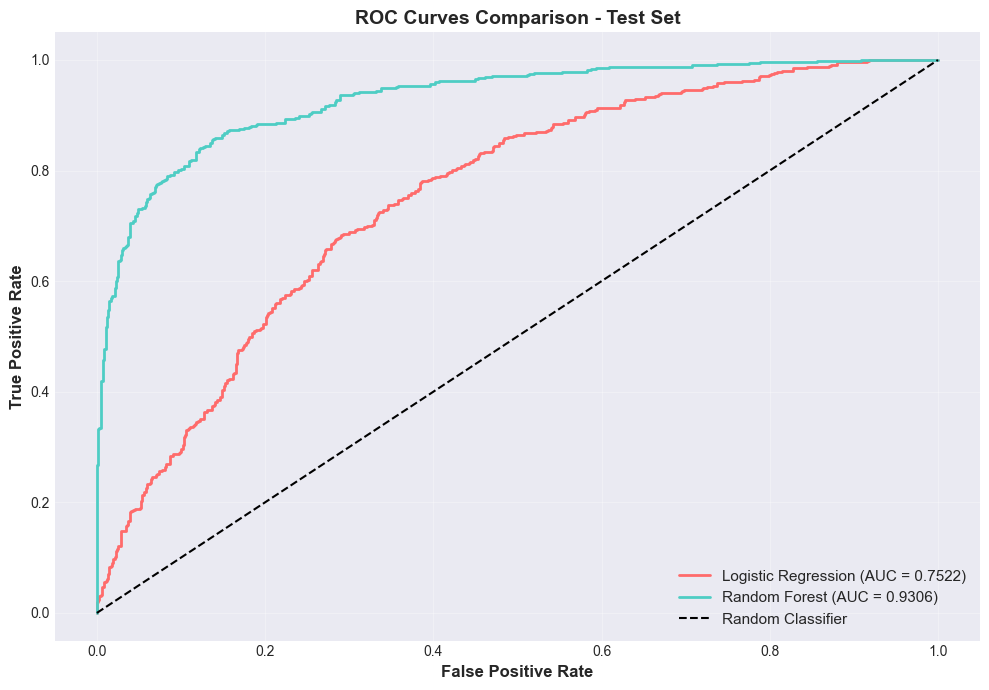

ROC Curves saved to 'reports/roc_curves.png'


In [11]:
# Calculate ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_test_pred_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_test_pred_proba)

# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_test_auc:.4f})', 
        linewidth=2, color='#FF6B6B')
ax.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_test_auc:.4f})', 
        linewidth=2, color='#4ECDC4')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves Comparison - Test Set', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reports/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("ROC Curves saved to 'reports/roc_curves.png'")

## Section 9: Generate Precision-Recall Curves

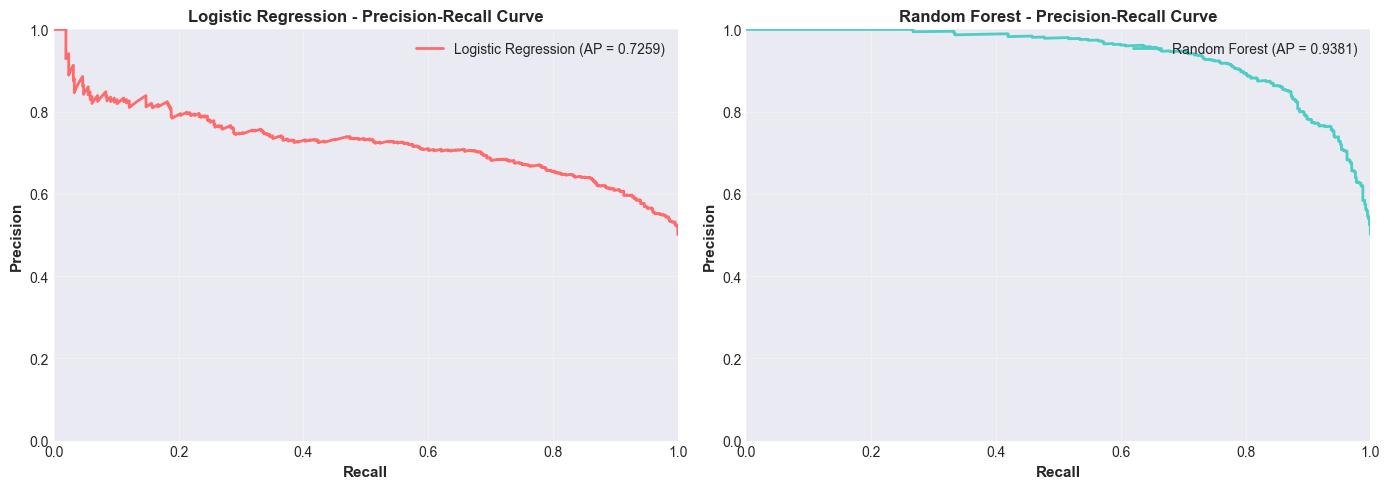

Precision-Recall Curves saved to 'reports/precision_recall_curves.png'


In [12]:
# Calculate Precision-Recall curves
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_test_pred_proba)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_test_pred_proba)

# Calculate Average Precision
from sklearn.metrics import average_precision_score
lr_ap = average_precision_score(y_test, lr_test_pred_proba)
rf_ap = average_precision_score(y_test, rf_test_pred_proba)

# Plot Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Precision-Recall
axes[0].plot(lr_recall, lr_precision, label=f'Logistic Regression (AP = {lr_ap:.4f})', 
             linewidth=2, color='#FF6B6B')
axes[0].set_xlabel('Recall', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[0].set_title('Logistic Regression - Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Random Forest Precision-Recall
axes[1].plot(rf_recall, rf_precision, label=f'Random Forest (AP = {rf_ap:.4f})', 
             linewidth=2, color='#4ECDC4')
axes[1].set_xlabel('Recall', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[1].set_title('Random Forest - Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('reports/precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Precision-Recall Curves saved to 'reports/precision_recall_curves.png'")

## Section 10: Create Confusion Matrix Visualizations

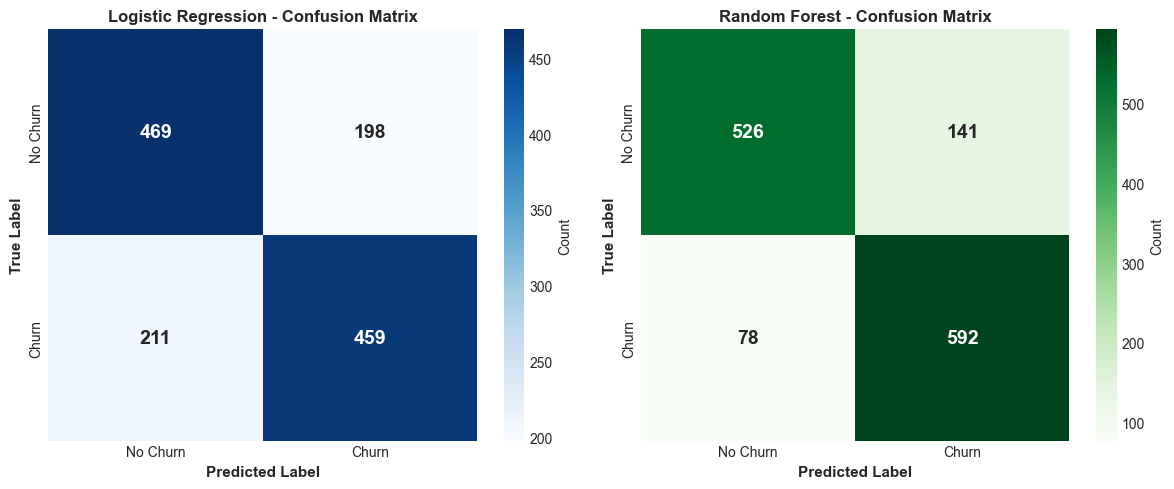

Confusion Matrices saved to 'reports/confusion_matrices.png'


In [13]:
# Generate confusion matrices
lr_cm = confusion_matrix(y_test, lr_test_pred)
rf_cm = confusion_matrix(y_test, rf_test_pred)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Logistic Regression - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
axes[0].set_xticklabels(['No Churn', 'Churn'])
axes[0].set_yticklabels(['No Churn', 'Churn'])

# Random Forest Confusion Matrix
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1], 
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title('Random Forest - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_yticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('reports/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion Matrices saved to 'reports/confusion_matrices.png'")

## Section 11: Compare Model Performance Metrics

MODEL PERFORMANCE COMPARISON (TEST SET)
           Logistic Regression  Random Forest
Accuracy                0.6941         0.8362
Precision               0.6986         0.8076
Recall                  0.6851         0.8836
F1-Score                0.6918         0.8439
ROC-AUC                 0.7522         0.9306


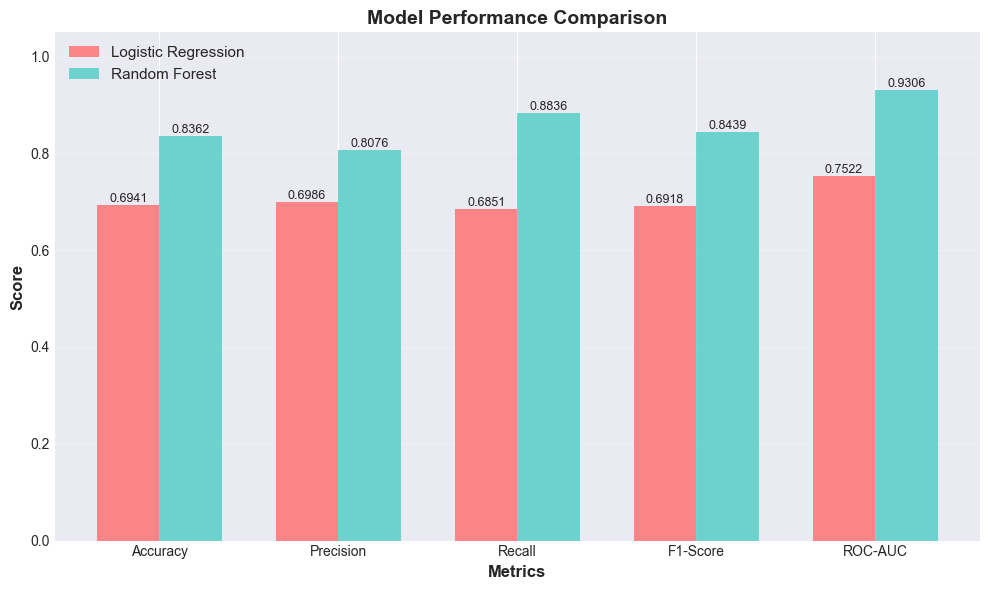


Detailed Classification Report:

--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.69      0.70      0.70       667
       Churn       0.70      0.69      0.69       670

    accuracy                           0.69      1337
   macro avg       0.69      0.69      0.69      1337
weighted avg       0.69      0.69      0.69      1337


--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.87      0.79      0.83       667
       Churn       0.81      0.88      0.84       670

    accuracy                           0.84      1337
   macro avg       0.84      0.84      0.84      1337
weighted avg       0.84      0.84      0.84      1337



In [14]:
# Calculate comprehensive metrics for both models
def calculate_metrics(y_true, y_pred, y_pred_proba):
    """Calculate comprehensive evaluation metrics"""
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_pred_proba)
    }
    return metrics

# Calculate metrics for both models
lr_metrics = calculate_metrics(y_test, lr_test_pred, lr_test_pred_proba)
rf_metrics = calculate_metrics(y_test, rf_test_pred, rf_test_pred_proba)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics
})

print("=" * 60)
print("MODEL PERFORMANCE COMPARISON (TEST SET)")
print("=" * 60)
print(comparison_df.round(4))
print("=" * 60)

# Create visualization of metric comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df.index))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Logistic Regression'], width, 
               label='Logistic Regression', color='#FF6B6B', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['Random Forest'], width, 
               label='Random Forest', color='#4ECDC4', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('reports/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDetailed Classification Report:")
print("\n--- Logistic Regression ---")
print(classification_report(y_test, lr_test_pred, target_names=['No Churn', 'Churn']))
print("\n--- Random Forest ---")
print(classification_report(y_test, rf_test_pred, target_names=['No Churn', 'Churn']))

## Section 12: Serialize the Best Model

In [15]:
# Identify the best model based on ROC-AUC score
print("=" * 60)
print("BEST MODEL SELECTION")
print("=" * 60)

lr_roc_auc = lr_metrics['ROC-AUC']
rf_roc_auc = rf_metrics['ROC-AUC']

if rf_roc_auc >= lr_roc_auc:
    best_model = rf_model
    best_model_name = "Random Forest"
    best_model_metrics = rf_metrics
else:
    best_model = lr_model
    best_model_name = "Logistic Regression"
    best_model_metrics = lr_metrics

print(f"\nBest Model: {best_model_name}")
print(f"ROC-AUC Score: {best_model_metrics['ROC-AUC']:.4f}")
print(f"Accuracy: {best_model_metrics['Accuracy']:.4f}")
print(f"F1-Score: {best_model_metrics['F1-Score']:.4f}")

# Serialize the best model
model_filename = f'models/best_churn_model_{best_model_name.replace(" ", "_").lower()}.pkl'

with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)

print(f"\n✓ Best model serialized and saved to: {model_filename}")

# Also save the scaler for future preprocessing
scaler_filename = 'models/feature_scaler.pkl'
with open(scaler_filename, 'wb') as f:
    pickle.dump(scaler, f)

print(f"✓ Feature scaler saved to: {scaler_filename}")

print("\n" + "=" * 60)
print("MODEL DEVELOPMENT COMPLETE!")
print("=" * 60)
print(f"\nAll artifacts saved in the project folders:")
print(f"  - Models: models/")
print(f"  - Reports/Visualizations: reports/")
print(f"  - Code: customer_churn_prediction.ipynb")

BEST MODEL SELECTION

Best Model: Random Forest
ROC-AUC Score: 0.9306
Accuracy: 0.8362
F1-Score: 0.8439

✓ Best model serialized and saved to: models/best_churn_model_random_forest.pkl
✓ Feature scaler saved to: models/feature_scaler.pkl

MODEL DEVELOPMENT COMPLETE!

All artifacts saved in the project folders:
  - Models: models/
  - Reports/Visualizations: reports/
  - Code: customer_churn_prediction.ipynb
